# Customer Investment Needs — Modeling

**Goal:** Train binary classifiers for each investment target, build an entropy-gated soft-vote ensemble, and flag uncertain predictions for human review using KNN neighbourhood disagreement.

**Inputs:** `processed_features.xlsx` — output of `0-DataPreprocessing.ipynb`

**Outputs:** `model_predictions.xlsx` — per-customer probabilities, ensemble predictions, and review flags — consumed by `2_next_best_action_system_design.ipynb`

---

## Notebook Structure

1. Imports & Setup
2. Load Processed Data
3. Train / Test Split
4. Scaling
5. Distance Matrix Construction
6. Model Evaluation Strategy
7. Modeling
8. Entropy-Gated Ensemble
9. Recommendations
10. Export

---
## 1. Imports & Setup

In [39]:
import importlib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import models as model_module
import plots
import utilities
from models import ModelFactory
from utilities import *

# Hot-reload during development
importlib.reload(plots)
importlib.reload(utilities)
importlib.reload(model_module)

sns.set_theme(style="darkgrid", context="notebook", palette="muted")
plt.rcParams.update({
    "figure.dpi":       110,
    "axes.titlesize":   12,
    "axes.labelsize":   10,
    "figure.facecolor": "#1a1a2e",
    "axes.facecolor":   "#16213e",
    "text.color":       "#e0e0e0",
    "axes.labelcolor":  "#e0e0e0",
    "xtick.color":      "#e0e0e0",
    "ytick.color":      "#e0e0e0",
})

SEED    = 42
TARGETS = ["IncomeInvestment", "AccumulationInvestment"]

---
## 2. Load Processed Data

Two sheets from `processed_features.xlsx`:
- `features` — engineered features
- `targets`  — two binary labels

In [9]:
input_path = "processed_features.xlsx"

feature_df = pd.read_excel(input_path, sheet_name="features", index_col=0)
targets_df = pd.read_excel(input_path, sheet_name="targets",  index_col=0)

print("features :", feature_df.shape)
print("targets  :", targets_df.shape)
print("\nClass balance:")
print(targets_df.mean().round(3))
feature_df.head()

features : (5000, 10)
targets  : (5000, 2)

Class balance:
IncomeInvestment          0.384
AccumulationInvestment    0.513
dtype: float64


,Age,FamilyMembers,FinancialEducation,RiskPropensity,Wealth_log,Income_log,IncomePerFamilyMember_log,Income_Wealth_Ratio_log,SophisticationScore,Gender
0,64,3,0.563402,0.582442,5.122047,5.048320,3.962466,0.656742,0.328149,0
1,57,2,0.197647,0.396081,4.219891,4.228070,3.549398,0.697306,0.078284,1
2,53,2,0.404948,0.407098,3.602428,3.398944,2.738659,0.593727,0.164854,0
3,67,3,0.610428,0.332732,4.726979,4.620627,3.541516,0.640910,0.203109,1
4,57,3,0.507142,0.501799,4.122068,4.141433,3.074125,0.703036,0.254484,1


In [10]:
NUMERICAL_FEATURES   = feature_df.select_dtypes(include="number").columns.tolist()
CATEGORICAL_FEATURES = feature_df.select_dtypes(exclude="number").columns.tolist()

print("Numerical  :", NUMERICAL_FEATURES)
print("Categorical:", CATEGORICAL_FEATURES)

Numerical  : ['Age', 'FamilyMembers', 'FinancialEducation', 'RiskPropensity', 'Wealth_log', 'Income_log', 'IncomePerFamilyMember_log', 'Income_Wealth_Ratio_log', 'SophisticationScore', 'Gender']
Categorical: []


---
## 3. Train / Test Split

Stratified 80/20 split applied **once** before any scaling. Stratification preserves class balance in both splits.

> **Leakage note:** The scaler is fit exclusively on `X_train_*` (§4). Distance-matrix construction (§5) also uses only the training features so that test-set geometry does not influence any upstream step.

In [11]:
income_series = targets_df["IncomeInvestment"]
accum_series  = targets_df["AccumulationInvestment"]

X_train_inc, X_test_inc, y_income_train, y_income_test = train_test_split(
    feature_df, income_series,
    test_size=0.2, random_state=SEED, stratify=income_series,
)

X_train_acc, X_test_acc, y_accum_train, y_accum_test = train_test_split(
    feature_df, accum_series,
    test_size=0.2, random_state=SEED, stratify=accum_series,
)

print(f"Income       — train: {len(X_train_inc):,}  test: {len(X_test_inc):,}")
print(f"Accumulation — train: {len(X_train_acc):,}  test: {len(X_test_acc):,}")

Income       — train: 4,000  test: 1,000
Accumulation — train: 4,000  test: 1,000


---
## 4. Scaling

`StandardScaler` is **fit on the training set only** and then applied to both train and test. Fitting on the full dataset before the split would leak test statistics into training.

In [12]:
# 1. Scalers (separate per target)
scaler_inc = StandardScaler()
scaler_acc = StandardScaler()

# 2. Income scaling
X_train_inc_scaled = pd.DataFrame(
    scaler_inc.fit_transform(X_train_inc[NUMERICAL_FEATURES]),
    columns=NUMERICAL_FEATURES,
    index=X_train_inc.index
)
X_test_inc_scaled = pd.DataFrame(
    scaler_inc.transform(X_test_inc[NUMERICAL_FEATURES]),
    columns=NUMERICAL_FEATURES,
    index=X_test_inc.index
)
for col in CATEGORICAL_FEATURES:
    X_train_inc_scaled[col] = X_train_inc[col].values
    X_test_inc_scaled[col]  = X_test_inc[col].values

# 3. Accumulation scaling
X_train_acc_scaled = pd.DataFrame(
    scaler_acc.fit_transform(X_train_acc[NUMERICAL_FEATURES]),
    columns=NUMERICAL_FEATURES,
    index=X_train_acc.index
)
X_test_acc_scaled = pd.DataFrame(
    scaler_acc.transform(X_test_acc[NUMERICAL_FEATURES]),
    columns=NUMERICAL_FEATURES,
    index=X_test_acc.index
)
for col in CATEGORICAL_FEATURES:
    X_train_acc_scaled[col] = X_train_acc[col].values
    X_test_acc_scaled[col]  = X_test_acc[col].values

# 4. Sanity checks
print("Income train means (should be ~0):")
print(X_train_inc_scaled[NUMERICAL_FEATURES].mean().round(3))
print("\nAccumulation train means (should be ~0):")
print(X_train_acc_scaled[NUMERICAL_FEATURES].mean().round(3))

Income train means (should be ~0):
Age                         -0.0
FamilyMembers               -0.0
FinancialEducation          -0.0
RiskPropensity              -0.0
Wealth_log                   0.0
Income_log                   0.0
IncomePerFamilyMember_log   -0.0
Income_Wealth_Ratio_log     -0.0
SophisticationScore          0.0
Gender                      -0.0
dtype: float64

Accumulation train means (should be ~0):
Age                          0.0
FamilyMembers                0.0
FinancialEducation          -0.0
RiskPropensity              -0.0
Wealth_log                  -0.0
Income_log                  -0.0
IncomePerFamilyMember_log    0.0
Income_Wealth_Ratio_log     -0.0
SophisticationScore          0.0
Gender                      -0.0
dtype: float64


---
## 5. Distance Matrix Construction

Built on **training features only** — the test set must not influence the neighbourhood structure used later in the KNN uncertainty step.

> **Design note:** Feature scaling (§4) ensures no single variable dominates Euclidean distances. Later stages may add feature weights to reflect financial relevance (e.g. risk propensity, income).

In [13]:
distance_matrix = pairwise_distances(X_train_inc_scaled, metric="euclidean")

print(f"Distance matrix shape : {distance_matrix.shape}")
print(f"Value range           : [{distance_matrix.min():.4f}, {distance_matrix.max():.4f}]")
print(f"Mean distance         : {distance_matrix.mean():.4f}")

assert np.allclose(np.diag(distance_matrix), 0, atol=1e-6), "Diagonal non-zero."
print("Diagonal check        : OK")

Distance matrix shape : (4000, 4000)
Value range           : [0.0000, 19.9675]
Mean distance         : 4.1878
Diagonal check        : OK


---
## 6. Model Evaluation Strategy

Binary labels: **Class 0** = not suitable, **Class 1** = suitable for a product. Because mis-recommending and missing relevant clients carry different costs, accuracy alone is insufficient. The framework uses three layered metrics:

| Metric | Type | Role |
|--------|------|------|
| Safety Constraint — Recall(class 0) ≥ 0.90 | Hard rule | Rejects models that pass too many bad recommendations |
| Safety-Constrained Precision | Hybrid | Primary selection metric — quality among safe models |
| Balanced Business Score | Soft | Comparison — coverage vs. precision trade-off |

**Why not accuracy?** It treats all errors equally, ignores class imbalance, and hides failures on the minority (but important) positive class.

---

## 7. Modeling

Each `run_experiment` executes a leakage-safe pipeline:

1. **Optional tuning** on `X_train` only
2. **Cross-validation on `X_train`** and single evaluation on `X_test`
3. **Final fit on full `X_train`** for inference
4. **Outputs:**
   - `y_prob_train`: used for analysis/ensemble design
   - `y_prob_test`: used for final evaluation
   - `y_pred_test`: final class predictions

This structure ensures clean separation between training, evaluation, and downstream ensemble usage.

### 7.1 Logistic Regression

A linear baseline classifier used as a calibration reference across both Income and Accumulation tasks. It performs well when relationships between features and the target are approximately linear. It is sensitive to feature scaling (handled in preprocessing) and serves as an interpretable benchmark for the ensemble.

---

### 7.2 XGBoost

A gradient-boosted tree model and the strongest nonlinear learner in this system. It captures complex feature interactions and nonlinear decision boundaries effectively. It is typically the best standalone performer on tabular data and a key contributor to ensemble performance.

---

### 7.3 K-Nearest Neighbors (KNN)

A distance-based model that relies heavily on feature scaling and local similarity structure. It performs well in locally smooth regions of the feature space but can degrade in high-dimensional or noisy settings. Its contribution is most useful in capturing local patterns missed by global models like XGBoost.

---

### 7.4 Support Vector Machine (SVM)

A margin-based classifier that finds an optimal separating hyperplane between classes. Its performance depends strongly on kernel choice and hyperparameter tuning. It is effective in medium-dimensional spaces but sensitive to scaling and data distribution shifts.

---

### 7.5 Gaussian Naive Bayes

A probabilistic generative model assuming conditional independence between features. Despite its simplicity, it provides a fast and stable baseline and can perform well in noisy regimes. However, it cannot capture complex feature interactions compared to ensemble methods.


TUNING SUMMARY
+---------------+--------------------+
|    Metric     |       Value        |
+---------------+--------------------+
|     Model     | LogisticRegression |
| Best CV Score |       0.6285       |
|  Best Params  |      C: 0.01       |
|               |    penalty: l1     |
|               | solver: liblinear  |
+---------------+--------------------+

LogisticRegression — Income
+-----------------+---------+--------+---------------+
|     Metric      | CV Mean | CV Std |   Test Set    |
+-----------------+---------+--------+---------------+
|    Accuracy     |  0.757  | 0.011  |     0.781     |
| Precision (0/1) |  0.749  | 0.025  | 0.784 / 0.774 |
|  Recall (0/1)   |  0.725  | 0.139  | 0.890 / 0.607 |
|    F1 (0/1)     |  0.732  | 0.084  | 0.833 / 0.680 |
|     Safety      |  -1.0   |  0.0   |     -1.0      |
|    Balanced     |  0.629  | 0.024  |     0.657     |
+-----------------+---------+--------+---------------+


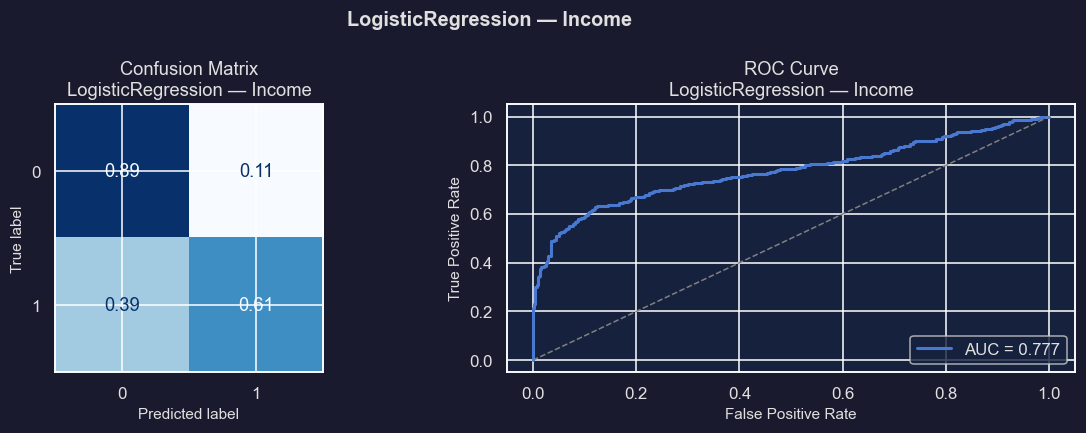


TUNING SUMMARY
+---------------+--------------------+
|    Metric     |       Value        |
+---------------+--------------------+
|     Model     | LogisticRegression |
| Best CV Score |       0.7008       |
|  Best Params  |       C: 0.1       |
|               |    penalty: l2     |
|               | solver: liblinear  |
+---------------+--------------------+

LogisticRegression — Accumulation
+-----------------+---------+--------+---------------+
|     Metric      | CV Mean | CV Std |   Test Set    |
+-----------------+---------+--------+---------------+
|    Accuracy     |  0.657  | 0.016  |     0.671     |
| Precision (0/1) |  0.658  | 0.018  | 0.674 / 0.668 |
|  Recall (0/1)   |  0.656  | 0.061  | 0.628 / 0.712 |
|    F1 (0/1)     |  0.655  | 0.031  | 0.650 / 0.689 |
|     Safety      |  -1.0   |  0.0   |     -1.0      |
|    Balanced     |  0.694  | 0.016  |     0.699     |
+-----------------+---------+--------+---------------+


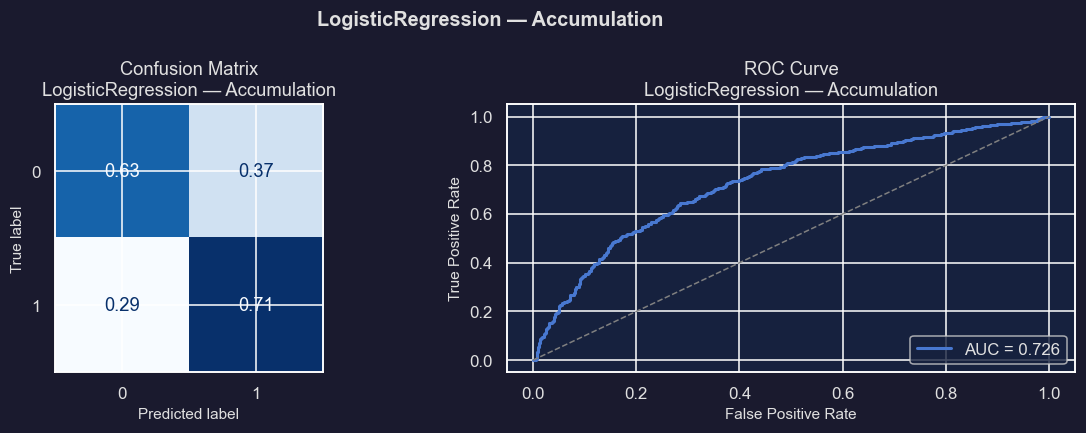


TUNING SUMMARY
+---------------+--------------------------------+
|    Metric     |             Value              |
+---------------+--------------------------------+
|     Model     |            XGBoost             |
| Best CV Score |             0.6859             |
|  Best Params  |     colsample_bytree: 0.5      |
|               |    gamma: 3.687707572929853    |
|               |       learning_rate: 0.2       |
|               |          max_depth: 6          |
|               |      min_child_weight: 6       |
|               |       n_estimators: 168        |
|               |         reg_alpha: 0.0         |
|               | reg_lambda: 0.1074496065562934 |
|               |         subsample: 1.0         |
+---------------+--------------------------------+

XGBoost — Income
+-----------------+---------+--------+---------------+
|     Metric      | CV Mean | CV Std |   Test Set    |
+-----------------+---------+--------+---------------+
|    Accuracy     |  0.815  | 0.016 

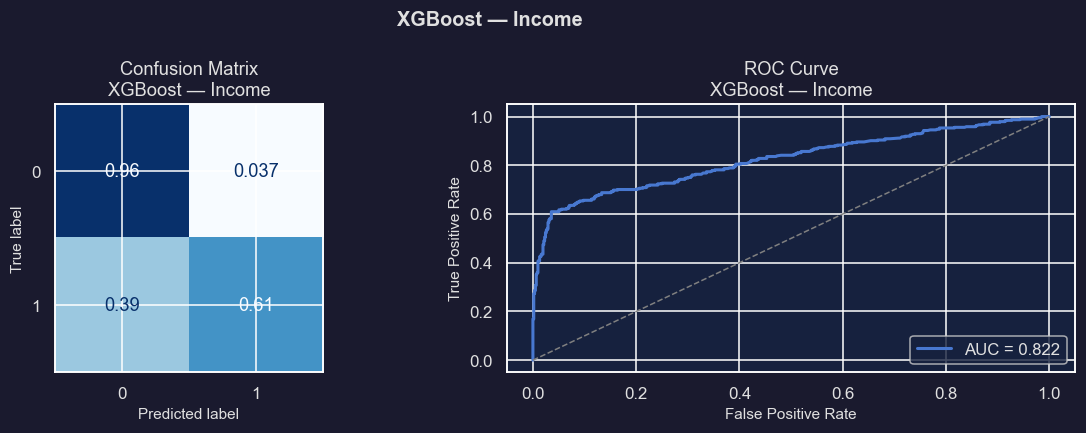


TUNING SUMMARY
+---------------+--------------------------------------+
|    Metric     |                Value                 |
+---------------+--------------------------------------+
|     Model     |               XGBoost                |
| Best CV Score |                0.7999                |
|  Best Params  | colsample_bytree: 0.9061979941786817 |
|               |      gamma: 0.8593578069828035       |
|               | learning_rate: 0.059989768591227254  |
|               |             max_depth: 5             |
|               |         min_child_weight: 6          |
|               |          n_estimators: 138           |
|               |    reg_alpha: 3.7790026641794077     |
|               |    reg_lambda: 5.562380663209308     |
|               |    subsample: 0.9559644307534418     |
+---------------+--------------------------------------+

XGBoost — Accumulation
+-----------------+---------+--------+---------------+
|     Metric      | CV Mean | CV Std |   Test Set 

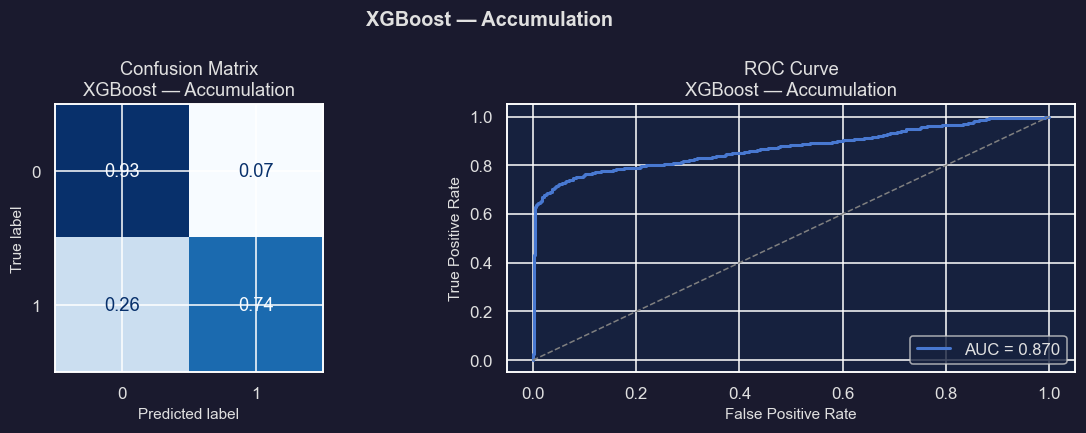


TUNING SUMMARY
+---------------+-------------------+
|    Metric     |       Value       |
+---------------+-------------------+
|     Model     |        KNN        |
| Best CV Score |      0.6003       |
|  Best Params  | metric: manhattan |
|               |  n_neighbors: 39  |
|               | weights: distance |
+---------------+-------------------+

KNN — Income
+-----------------+---------+--------+---------------+
|     Metric      | CV Mean | CV Std |   Test Set    |
+-----------------+---------+--------+---------------+
|    Accuracy     |  0.767  |  0.01  |     0.794     |
| Precision (0/1) |  0.785  | 0.037  | 0.770 / 0.871 |
|  Recall (0/1)   |  0.717  | 0.215  | 0.950 / 0.544 |
|    F1 (0/1)     |  0.727  | 0.105  | 0.850 / 0.670 |
|     Safety      |  0.82   | 0.018  |     0.871     |
|    Balanced     |  0.598  |  0.02  |     0.642     |
+-----------------+---------+--------+---------------+


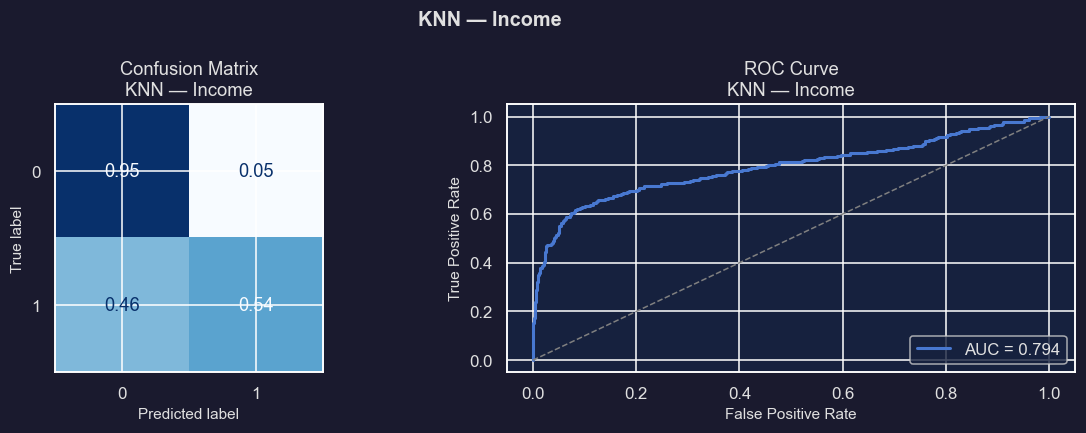


TUNING SUMMARY
+---------------+-------------------+
|    Metric     |       Value       |
+---------------+-------------------+
|     Model     |        KNN        |
| Best CV Score |      0.7344       |
|  Best Params  | metric: manhattan |
|               |  n_neighbors: 22  |
|               | weights: distance |
+---------------+-------------------+

KNN — Accumulation
+-----------------+---------+--------+---------------+
|     Metric      | CV Mean | CV Std |   Test Set    |
+-----------------+---------+--------+---------------+
|    Accuracy     |  0.746  | 0.016  |     0.752     |
| Precision (0/1) |  0.748  | 0.034  | 0.722 / 0.787 |
|  Recall (0/1)   |  0.747  | 0.044  | 0.799 / 0.708 |
|    F1 (0/1)     |  0.746  | 0.017  | 0.758 / 0.745 |
|     Safety      |  -1.0   |  0.0   |     -1.0      |
|    Balanced     |  0.729  | 0.019  |     0.732     |
+-----------------+---------+--------+---------------+


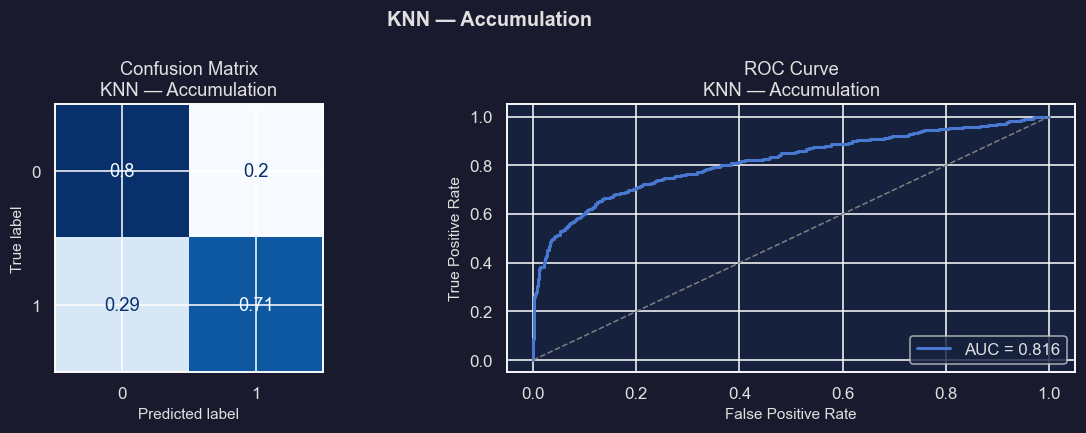


✔ Completed all experiments

Models trained:
 - logistic_income
 - logistic_accum
 - xgb_income
 - xgb_accum
 - knn_income
 - knn_accum

Income models: ['logistic', 'xgb', 'knn']
Accum models: ['logistic', 'xgb', 'knn']


In [14]:
import numpy as np

# 1. MODEL REGISTRY (ADD / REMOVE MODELS HERE)
MODEL_LIST = [
              "logistic",
              "xgb",
              "knn",
#              "svm",
#              "gnb"
]

# 2. STORAGE
model_outputs_income = []
model_outputs_accum = []

# 3. RUN ALL EXPERIMENTS

trained_models = {}

for model_name in MODEL_LIST:

    # =========================
    # INCOME
    # =========================
    inc_model, inc_results, inc_train_prob, inc_test_prob, inc_preds = run_experiment(
        model_name, "Income",
        X_train_inc_scaled, y_income_train,
        X_test_inc_scaled, y_income_test,
        tune=True
    )

    # =========================
    # ACCUMULATION
    # =========================
    acc_model, acc_results, acc_train_prob, acc_test_prob, acc_preds = run_experiment(
        model_name, "Accumulation",
        X_train_acc_scaled, y_accum_train,
        X_test_acc_scaled, y_accum_test,
        tune=True
    )

    # ========================================================
    # STORE MODELS
    # ========================================================
    trained_models[f"{model_name}_income"] = inc_model
    trained_models[f"{model_name}_accum"] = acc_model

    # ========================================================
    # BUILD CLEAN STRUCTURES (FOR ENSEMBLING)
    # ========================================================

    model_outputs_income.append({
        "name": model_name,
        "train_prob": np.asarray(inc_train_prob),
        "test_prob": np.asarray(inc_test_prob),
        "y_train": y_income_train.values,
        "y_test": y_income_test.values,
    })

    model_outputs_accum.append({
        "name": model_name,
        "train_prob": np.asarray(acc_train_prob),
        "test_prob": np.asarray(acc_test_prob),
        "y_train": y_accum_train.values,
        "y_test": y_accum_test.values,
    })


# ============================================================
# 4. FINAL OUTPUT STRUCTURE
# ============================================================

print("\n✔ Completed all experiments")

print("\nModels trained:")
for k in trained_models:
    print(" -", k)

print("\nIncome models:", [m["name"] for m in model_outputs_income])
print("Accum models:", [m["name"] for m in model_outputs_accum])

#### Feature Importance

Visualise which features drive each model's predictions.


--- Income Model: xgb ---


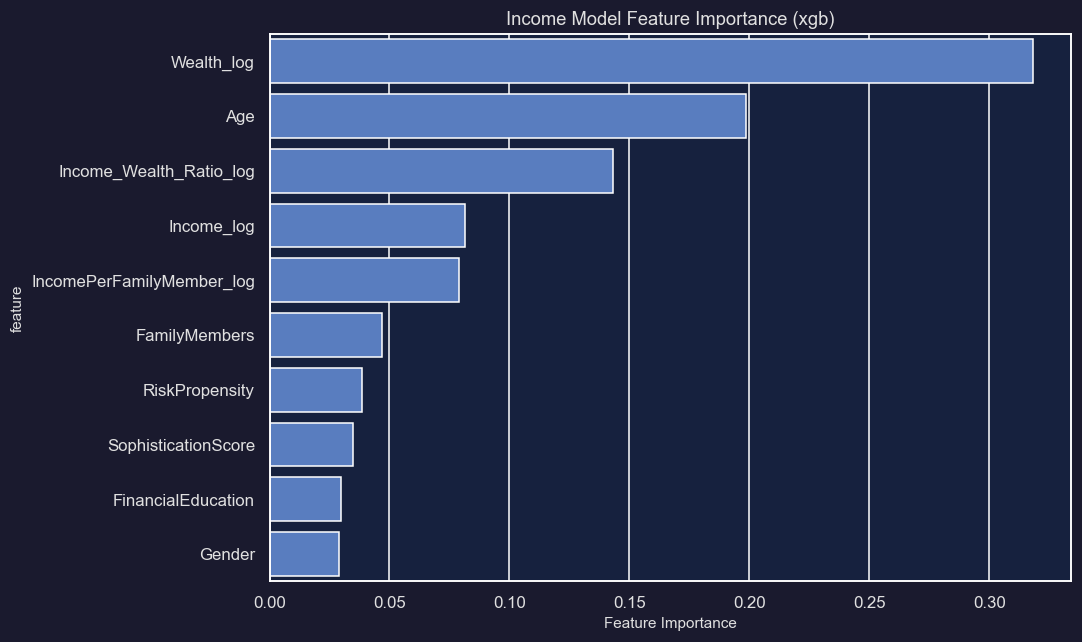


--- Accumulation Model: xgb ---


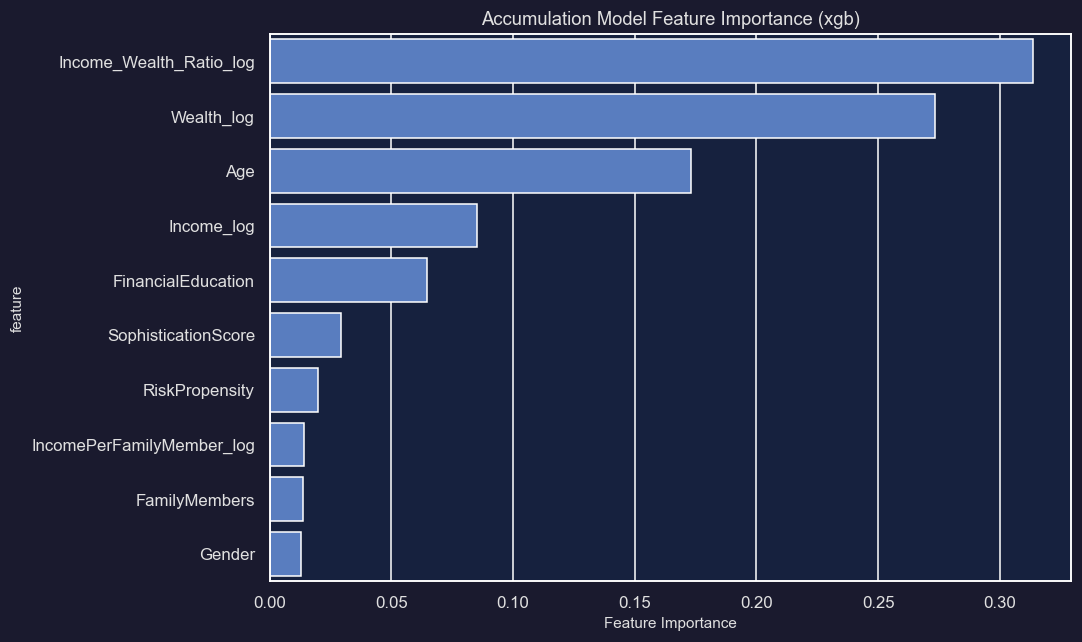

In [15]:
MODEL_LIST_feature_importance = ["xgb"]
# ============================================================
# 2. FEATURE IMPORTANCE PLOTTING (INCOME)
# ============================================================

for model_name in MODEL_LIST_feature_importance:
    key = f"{model_name}_income"
    model = trained_models[key]
    print(f"\n--- Income Model: {model_name} ---")
    plot_feature_importance(model,X_train_inc_scaled.columns,f"Income Model Feature Importance ({model_name})")


# ============================================================
# 3. FEATURE IMPORTANCE PLOTTING (ACCUMULATION)
# ============================================================

for model_name in MODEL_LIST_feature_importance:

    key = f"{model_name}_accum"
    model = trained_models[key]

    print(f"\n--- Accumulation Model: {model_name} ---")

    plot_feature_importance(
        model,
        X_train_acc_scaled.columns,
        f"Accumulation Model Feature Importance ({model_name})"
    )

#### Entropy Diagnostics

Entropy $H = -p\log_2 p - (1-p)\log_2(1-p)$ measures model uncertainty. Two uses:

- **Training set** — identify the top 5% noisiest samples for future active-learning relabelling.
- **Test set** — regulatory diagnostic: confident predictions should be far more accurate than uncertain ones, proving the model knows its own limits.

In [16]:
income_entropy_splits = {}
accum_entropy_splits = {}

for model_name in MODEL_LIST:

    # ============================================================
    # INCOME
    # ============================================================

    inc_model = trained_models[f"{model_name}_income"]

    inc_train_proba = inc_model.predict_proba(X_train_inc_scaled)[:, 1]

    clean_inc, review_inc, thr_inc = split_by_entropy(
        X_train_inc_scaled,
        y_income_train,
        inc_train_proba,
        top_percent=0.05,
    )

    income_entropy_splits[model_name] = {
        "clean": clean_inc,
        "review": review_inc,
        "threshold": thr_inc
    }

    # ============================================================
    # ACCUMULATION
    # ============================================================

    acc_model = trained_models[f"{model_name}_accum"]

    acc_train_proba = acc_model.predict_proba(X_train_acc_scaled)[:, 1]

    clean_acc, review_acc, thr_acc = split_by_entropy(
        X_train_acc_scaled,
        y_accum_train,
        acc_train_proba,
        top_percent=0.05,
    )

    accum_entropy_splits[model_name] = {
        "clean": clean_acc,
        "review": review_acc,
        "threshold": thr_acc
    }

    # ============================================================
    # PRINT SUMMARY
    # ============================================================

    print(f"\n[{model_name.upper()}]")

    print(f"Income       — clean: {len(clean_inc):,}  review: {len(review_inc):,}")
    print(f"Accumulation — clean: {len(clean_acc):,}  review: {len(review_acc):,}")


[LOGISTIC]
Income       — clean: 3,800  review: 200
Accumulation — clean: 3,800  review: 200

[XGB]
Income       — clean: 3,800  review: 200
Accumulation — clean: 3,800  review: 200

[KNN]
Income       — clean: 3,800  review: 200
Accumulation — clean: 3,800  review: 200



[LOGISTIC]
Income       — clean: 3,800  review: 200
Accumulation — clean: 3,800  review: 200


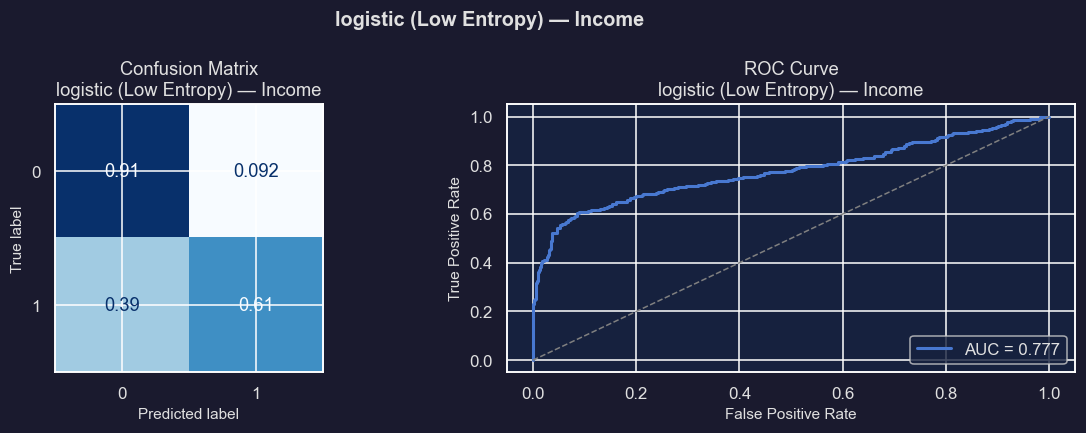


logistic (Low Entropy) — Income
+-----------------+---------+--------+----------+
|     Metric      | CV Mean | CV Std | Test Set |
+-----------------+---------+--------+----------+
|    Accuracy     |   nan   |  nan   |  0.795   |
| Precision (0/1) |   nan   |  nan   |  0.796   |
|  Recall (0/1)   |   nan   |  nan   |  0.795   |
|    F1 (0/1)     |   nan   |  nan   |  0.788   |
|     Safety      |   nan   |  nan   |  0.803   |
|    Balanced     |   nan   |  nan   |  0.667   |
+-----------------+---------+--------+----------+


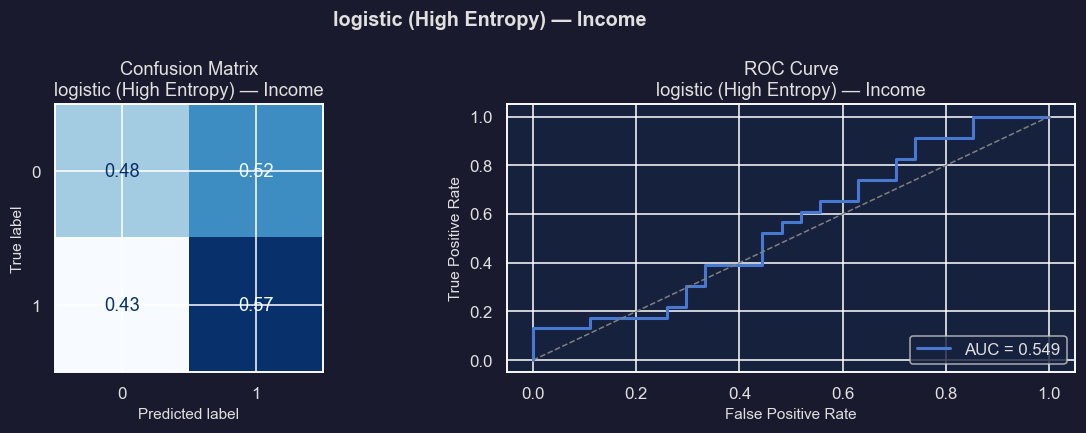


logistic (High Entropy) — Income
+-----------------+---------+--------+----------+
|     Metric      | CV Mean | CV Std | Test Set |
+-----------------+---------+--------+----------+
|    Accuracy     |   nan   |  nan   |   0.52   |
| Precision (0/1) |   nan   |  nan   |  0.527   |
|  Recall (0/1)   |   nan   |  nan   |   0.52   |
|    F1 (0/1)     |   nan   |  nan   |   0.52   |
|     Safety      |   nan   |  nan   |   -1.0   |
|    Balanced     |   nan   |  nan   |   0.54   |
+-----------------+---------+--------+----------+
⚠️ WARNING: High Entropy set violates safety constraint!


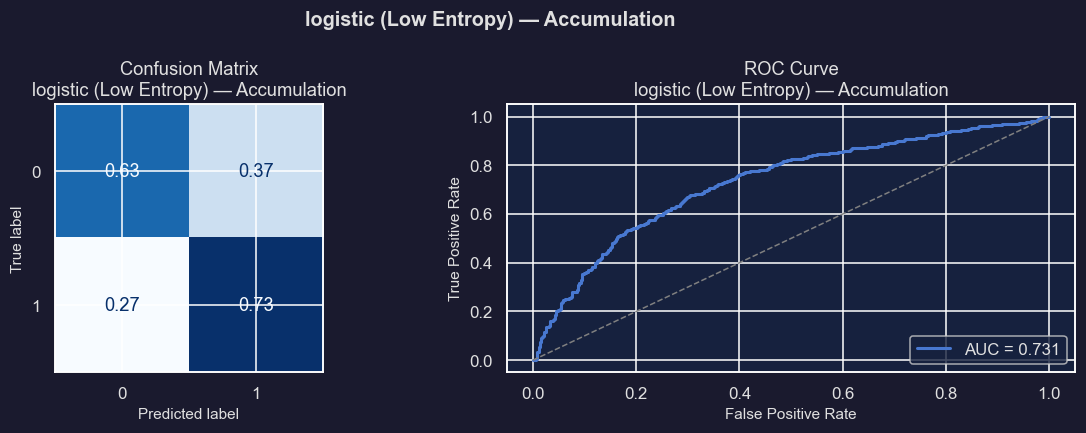


logistic (Low Entropy) — Accumulation
+-----------------+---------+--------+----------+
|     Metric      | CV Mean | CV Std | Test Set |
+-----------------+---------+--------+----------+
|    Accuracy     |   nan   |  nan   |   0.68   |
| Precision (0/1) |   nan   |  nan   |   0.68   |
|  Recall (0/1)   |   nan   |  nan   |   0.68   |
|    F1 (0/1)     |   nan   |  nan   |  0.679   |
|     Safety      |   nan   |  nan   |   -1.0   |
|    Balanced     |   nan   |  nan   |  0.712   |
+-----------------+---------+--------+----------+
⚠️ WARNING: Low Entropy set violates safety constraint!


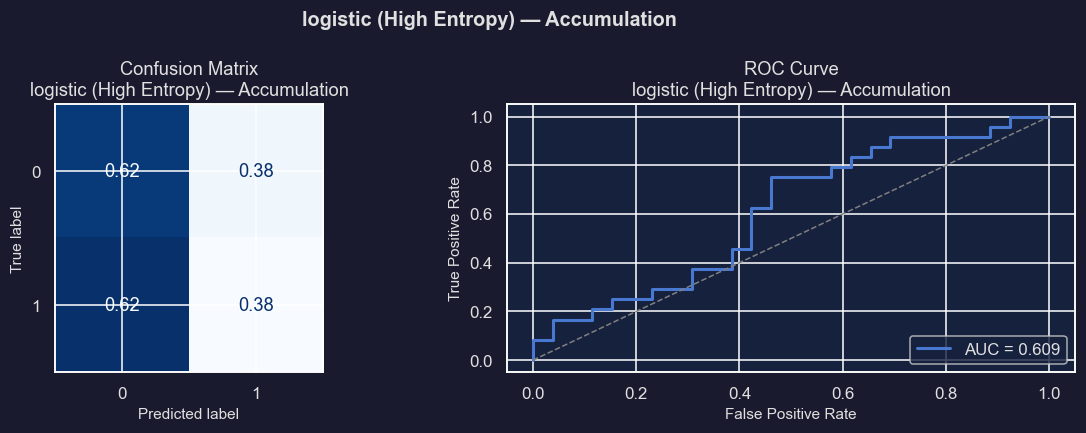


logistic (High Entropy) — Accumulation
+-----------------+---------+--------+----------+
|     Metric      | CV Mean | CV Std | Test Set |
+-----------------+---------+--------+----------+
|    Accuracy     |   nan   |  nan   |   0.5    |
| Precision (0/1) |   nan   |  nan   |  0.496   |
|  Recall (0/1)   |   nan   |  nan   |   0.5    |
|    F1 (0/1)     |   nan   |  nan   |  0.493   |
|     Safety      |   nan   |  nan   |   -1.0   |
|    Balanced     |   nan   |  nan   |  0.405   |
+-----------------+---------+--------+----------+
⚠️ WARNING: High Entropy set violates safety constraint!

[XGB]
Income       — clean: 3,800  review: 200
Accumulation — clean: 3,800  review: 200


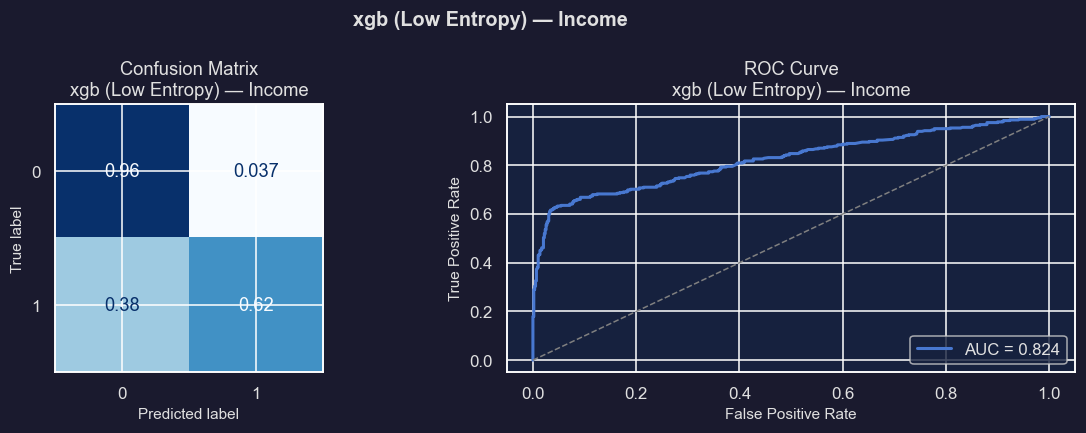


xgb (Low Entropy) — Income
+-----------------+---------+--------+----------+
|     Metric      | CV Mean | CV Std | Test Set |
+-----------------+---------+--------+----------+
|    Accuracy     |   nan   |  nan   |  0.832   |
| Precision (0/1) |   nan   |  nan   |  0.845   |
|  Recall (0/1)   |   nan   |  nan   |  0.832   |
|    F1 (0/1)     |   nan   |  nan   |  0.823   |
|     Safety      |   nan   |  nan   |  0.911   |
|    Balanced     |   nan   |  nan   |  0.706   |
+-----------------+---------+--------+----------+


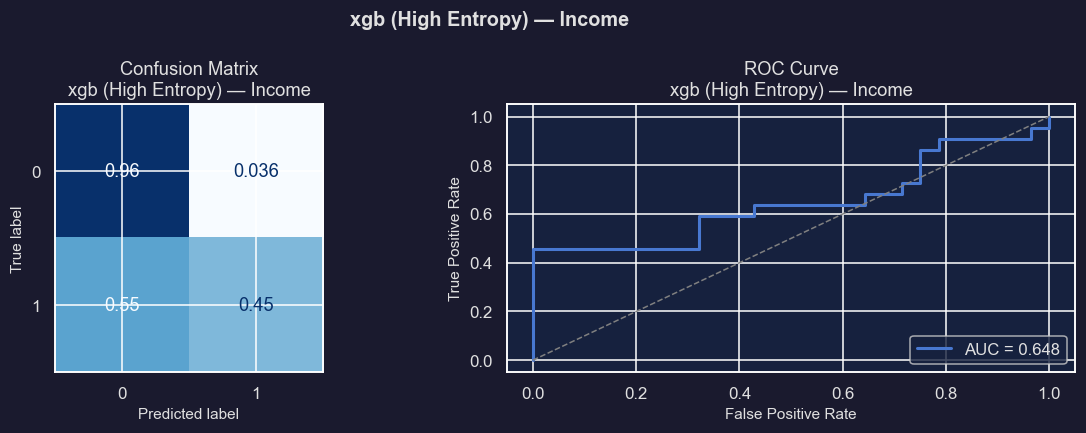


xgb (High Entropy) — Income
+-----------------+---------+--------+----------+
|     Metric      | CV Mean | CV Std | Test Set |
+-----------------+---------+--------+----------+
|    Accuracy     |   nan   |  nan   |   0.74   |
| Precision (0/1) |   nan   |  nan   |  0.788   |
|  Recall (0/1)   |   nan   |  nan   |   0.74   |
|    F1 (0/1)     |   nan   |  nan   |  0.718   |
|     Safety      |   nan   |  nan   |  0.909   |
|    Balanced     |   nan   |  nan   |  0.591   |
+-----------------+---------+--------+----------+


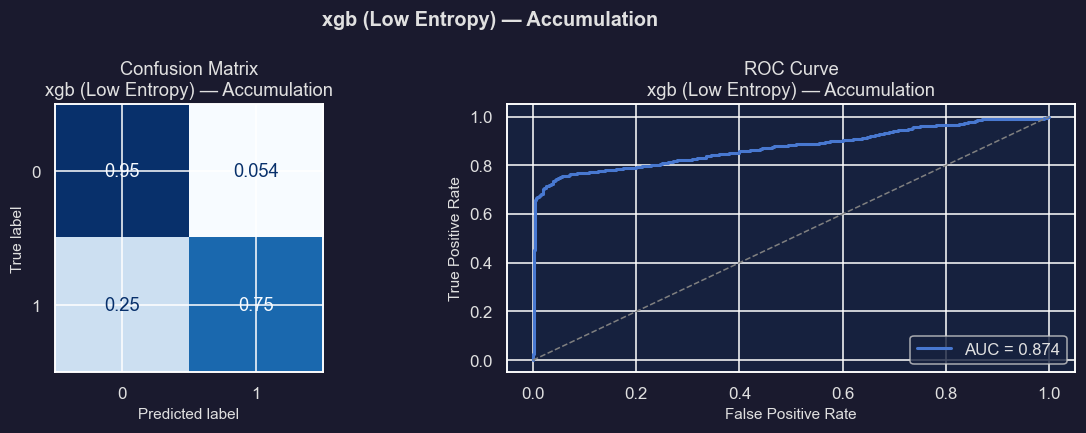


xgb (Low Entropy) — Accumulation
+-----------------+---------+--------+----------+
|     Metric      | CV Mean | CV Std | Test Set |
+-----------------+---------+--------+----------+
|    Accuracy     |   nan   |  nan   |  0.846   |
| Precision (0/1) |   nan   |  nan   |  0.862   |
|  Recall (0/1)   |   nan   |  nan   |  0.846   |
|    F1 (0/1)     |   nan   |  nan   |  0.845   |
|     Safety      |   nan   |  nan   |  0.937   |
|    Balanced     |   nan   |  nan   |  0.808   |
+-----------------+---------+--------+----------+


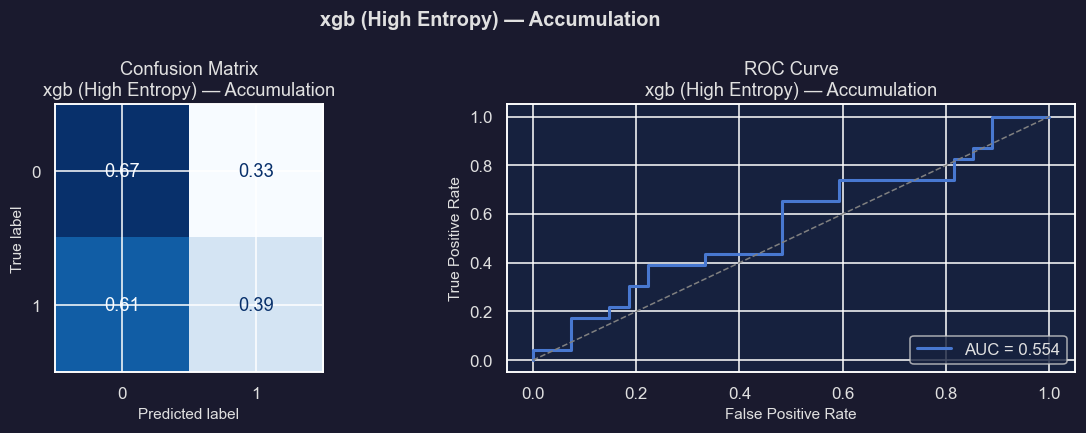


xgb (High Entropy) — Accumulation
+-----------------+---------+--------+----------+
|     Metric      | CV Mean | CV Std | Test Set |
+-----------------+---------+--------+----------+
|    Accuracy     |   nan   |  nan   |   0.54   |
| Precision (0/1) |   nan   |  nan   |  0.534   |
|  Recall (0/1)   |   nan   |  nan   |   0.54   |
|    F1 (0/1)     |   nan   |  nan   |  0.531   |
|     Safety      |   nan   |  nan   |   -1.0   |
|    Balanced     |   nan   |  nan   |  0.424   |
+-----------------+---------+--------+----------+
⚠️ WARNING: High Entropy set violates safety constraint!

[KNN]
Income       — clean: 3,800  review: 200
Accumulation — clean: 3,800  review: 200


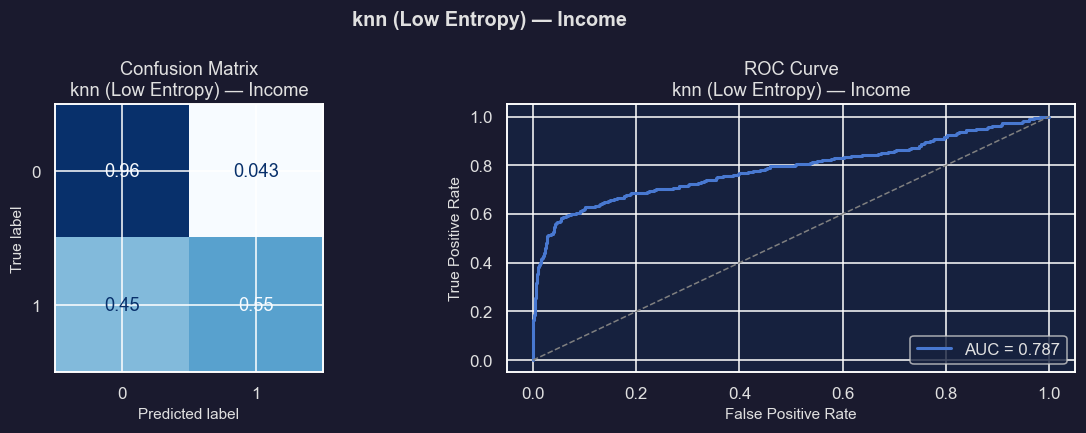


knn (Low Entropy) — Income
+-----------------+---------+--------+----------+
|     Metric      | CV Mean | CV Std | Test Set |
+-----------------+---------+--------+----------+
|    Accuracy     |   nan   |  nan   |  0.806   |
| Precision (0/1) |   nan   |  nan   |   0.82   |
|  Recall (0/1)   |   nan   |  nan   |  0.806   |
|    F1 (0/1)     |   nan   |  nan   |  0.794   |
|     Safety      |   nan   |  nan   |  0.882   |
|    Balanced     |   nan   |  nan   |   0.65   |
+-----------------+---------+--------+----------+


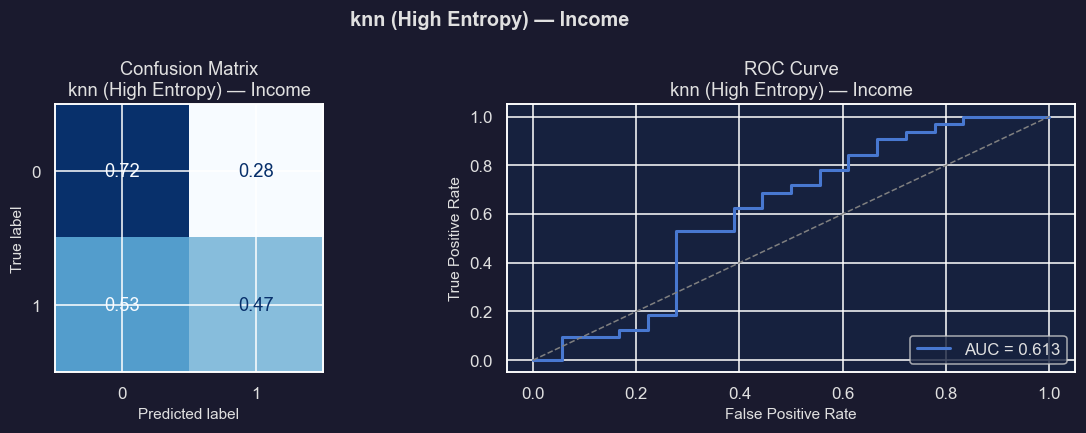


knn (High Entropy) — Income
+-----------------+---------+--------+----------+
|     Metric      | CV Mean | CV Std | Test Set |
+-----------------+---------+--------+----------+
|    Accuracy     |   nan   |  nan   |   0.56   |
| Precision (0/1) |   nan   |  nan   |  0.636   |
|  Recall (0/1)   |   nan   |  nan   |   0.56   |
|    F1 (0/1)     |   nan   |  nan   |  0.564   |
|     Safety      |   nan   |  nan   |   -1.0   |
|    Balanced     |   nan   |  nan   |  0.553   |
+-----------------+---------+--------+----------+
⚠️ WARNING: High Entropy set violates safety constraint!


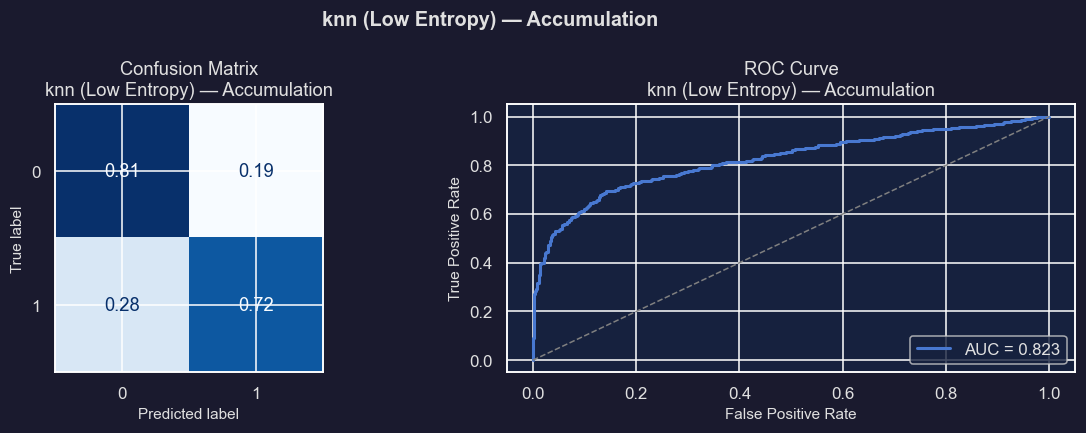


knn (Low Entropy) — Accumulation
+-----------------+---------+--------+----------+
|     Metric      | CV Mean | CV Std | Test Set |
+-----------------+---------+--------+----------+
|    Accuracy     |   nan   |  nan   |  0.763   |
| Precision (0/1) |   nan   |  nan   |  0.767   |
|  Recall (0/1)   |   nan   |  nan   |  0.763   |
|    F1 (0/1)     |   nan   |  nan   |  0.763   |
|     Safety      |   nan   |  nan   |   -1.0   |
|    Balanced     |   nan   |  nan   |  0.743   |
+-----------------+---------+--------+----------+
⚠️ WARNING: Low Entropy set violates safety constraint!


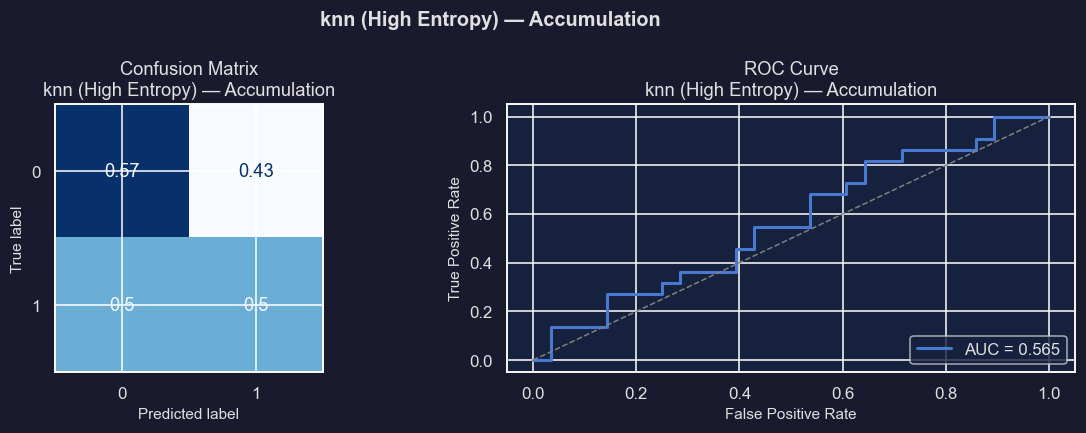


knn (High Entropy) — Accumulation
+-----------------+---------+--------+----------+
|     Metric      | CV Mean | CV Std | Test Set |
+-----------------+---------+--------+----------+
|    Accuracy     |   nan   |  nan   |   0.54   |
| Precision (0/1) |   nan   |  nan   |  0.542   |
|  Recall (0/1)   |   nan   |  nan   |   0.54   |
|    F1 (0/1)     |   nan   |  nan   |  0.541   |
|     Safety      |   nan   |  nan   |   -1.0   |
|    Balanced     |   nan   |  nan   |  0.493   |
+-----------------+---------+--------+----------+
⚠️ WARNING: High Entropy set violates safety constraint!


In [17]:
# ============================================================
# STORAGE
# ============================================================

entropy_train_splits = {
    "income": {},
    "accum": {},
}
entropy_test_results = {
    "income": {},
    "accum": {},
}

for model_name in MODEL_LIST:

    inc_model = trained_models[f"{model_name}_income"]
    acc_model = trained_models[f"{model_name}_accum"]

    # ============================================================
    # ENTROPY SPLIT ON TRAIN
    # ============================================================

    clean_income_train, review_income_train, thr_income_train = split_by_entropy(
        X_train_inc_scaled, y_income_train,
        inc_model.predict_proba(X_train_inc_scaled)[:, 1],
        top_percent=0.05,
    )
    clean_accum_train, review_accum_train, thr_accum_train = split_by_entropy(
        X_train_acc_scaled, y_accum_train,
        acc_model.predict_proba(X_train_acc_scaled)[:, 1],
        top_percent=0.05,
    )

    entropy_train_splits["income"][model_name] = {
        "clean":     clean_income_train,
        "review":    review_income_train,
        "threshold": thr_income_train,
    }
    entropy_train_splits["accum"][model_name] = {
        "clean":     clean_accum_train,
        "review":    review_accum_train,
        "threshold": thr_accum_train,
    }

    print(f"\n[{model_name.upper()}]")
    print(f"Income       — clean: {len(clean_income_train):,}  review: {len(review_income_train):,}")
    print(f"Accumulation — clean: {len(clean_accum_train):,}  review: {len(review_accum_train):,}")

    # ============================================================
    # ENTROPY DIAGNOSTICS ON TEST
    # ============================================================

    inc_test_prob = inc_model.predict_proba(X_test_inc_scaled)[:, 1]
    inc_test_pred = (inc_test_prob >= 0.5).astype(int)

    acc_test_prob = acc_model.predict_proba(X_test_acc_scaled)[:, 1]
    acc_test_pred = (acc_test_prob >= 0.5).astype(int)

    inc_test_diagnostics = evaluate_entropy_splits(
        inc_model, X_test_inc_scaled, y_income_test, inc_test_pred, inc_test_prob,
        model_name, "Income", alpha=0.05,
    )
    acc_test_diagnostics = evaluate_entropy_splits(
        acc_model, X_test_acc_scaled, y_accum_test, acc_test_pred, acc_test_prob,
        model_name, "Accumulation", alpha=0.05,
    )

    entropy_test_results["income"][model_name] = {
        "prob":        inc_test_prob,
        "pred":        inc_test_pred,
        "diagnostics": inc_test_diagnostics,
    }
    entropy_test_results["accum"][model_name] = {
        "prob":        acc_test_prob,
        "pred":        acc_test_pred,
        "diagnostics": acc_test_diagnostics,
    }

### Summary of Results

The analysis shows that XGBoost is the strongest performing model overall, but all models degrade significantly under high-entropy conditions, especially with respect to safety constraints.

#### Key Findings

- **XGBoost is the Best Performer**
  - Outperforms Logistic Regression and KNN on both tasks.
  - Achieves highest accuracy on Low Entropy datasets:
    - Income: 0.838
    - Accumulation: 0.844
  - Is the only model that passes the safety constraint on both Low Entropy tasks.

- **High Entropy Severely Degrades Performance**
  - All models experience a major drop in accuracy when moving from Low Entropy to High Entropy data.
  - Accuracy often falls into the ~40–60% range, close to random guessing for binary classification.

- **Universal Safety Failures on High Entropy**
  - Every model fails the safety constraint (Safety = -1.0) on High Entropy datasets.
  - This indicates that high-entropy data is currently unsafe for all tested configurations.

- **Accumulation Target is More Difficult**
  - Income prediction performs relatively well under Low Entropy across models.
  - Accumulation is harder:
    - Logistic Regression and KNN fail the safety constraint even under Low Entropy.
    - Only XGBoost successfully meets both performance and safety requirements for Accumulation.

#### Overall Conclusion
XGBoost is the only consistently reliable model, especially under low-entropy conditions. However, none of the models are robust or safe under high-entropy data, indicating a fundamental limitation in handling more complex or noisy distributions.



In [44]:

# ============================================================
# 2. BUILD WRAPPER LISTS FROM trained_models
# ============================================================

models_income = [trained_models[f"{name}_income"] for name in MODEL_LIST]
models_accum  = [trained_models[f"{name}_accum"]  for name in MODEL_LIST]

# ============================================================
# GENERATE OOF PREDICTIONS
# ============================================================

print("Computing OOF predictions for Income meta-model...")
oof_matrix_income = compute_oof_matrix(models_income, X_train_inc_scaled, y_income_train)

print("\nComputing OOF predictions for Accumulation meta-model...")
oof_matrix_accum = compute_oof_matrix(models_accum, X_train_acc_scaled, y_accum_train)

# 4. FIT META-MODELS VIA ModelFactory

print("\nTuning & Fitting Meta-Models...")
meta_income = ModelFactory.create("xgb")
meta_accum  = ModelFactory.create("xgb")

print("\n[Income] Tuning meta-model...")
meta_income.tune(oof_matrix_income, y_income_train)
print(f"  Best params : {meta_income.best_params}")
print(f"  Best score  : {meta_income.tuning_results['best_score']:.4f}")

print("\n[Accum] Tuning meta-model...")
meta_accum.tune(oof_matrix_accum, y_accum_train)
print(f"  Best params : {meta_accum.best_params}")
print(f"  Best score  : {meta_accum.tuning_results['best_score']:.4f}")

# train() will automatically apply best_params_ (set inside _store_tuning)
meta_income.train(oof_matrix_income, y_income_train)
meta_accum.train(oof_matrix_accum,   y_accum_train)

# ============================================================
# PRINT META-MODEL COEFFICIENTS (WEIGHTS)
# ============================================================
#
# print("\nMeta-Model Coefficients (Base Model Weights):")
#
# print("\n[Income] Model Weights:")
# # We use .trained_model.coef_[0] because it's a binary classifier
# for wrapper, coef in zip(models_income, meta_income.trained_model.coef_[0]):
#     print(f"  {wrapper.name:20s} — Weight: {coef:>7.4f}")
#
# print("\n[Accum] Model Weights:")
# for wrapper, coef in zip(models_accum, meta_accum.trained_model.coef_[0]):
#     print(f"  {wrapper.name:20s} — Weight: {coef:>7.4f}")
print("\nMeta-Model Feature Importances (Base Model Contributions):")

print("\n[Income] Model Importances:")
# 2. Use feature_importances_ instead of coef_[0]
for wrapper, imp in zip(models_income, meta_income.trained_model.feature_importances_):
    print(f"  {wrapper.name:20s} — Importance: {imp:>7.4f}")

print("\n[Accum] Model Importances:")
for wrapper, imp in zip(models_accum, meta_accum.trained_model.feature_importances_):
    print(f"  {wrapper.name:20s} — Importance: {imp:>7.4f}")



# ============================================================
# 5. BUILD TEST MATRICES & GENERATE ENSEMBLE PROBABILITIES
# ============================================================

test_matrix_income = build_test_matrix(models_income, X_test_inc_scaled)
test_matrix_accum  = build_test_matrix(models_accum,  X_test_acc_scaled)

ensemble_income_prob = meta_income.predict_proba(test_matrix_income)[:, 1]
ensemble_accum_prob  = meta_accum.predict_proba(test_matrix_accum)[:, 1]

print("\nEnsemble statistics:")
print(f"  Income — mean: {ensemble_income_prob.mean():.3f}  std: {ensemble_income_prob.std():.3f}")
print(f"  Accum  — mean: {ensemble_accum_prob.mean():.3f}  std: {ensemble_accum_prob.std():.3f}")

print("\n✓ Stacking ensemble fitted safely on OOF train signals, evaluated on TEST set.")

Computing OOF predictions for Income meta-model...
  LogisticRegression   — OOF mean: 0.415  std: 0.175
  XGBoost              — OOF mean: 0.385  std: 0.274
  KNN                  — OOF mean: 0.364  std: 0.213

Computing OOF predictions for Accumulation meta-model...
  LogisticRegression   — OOF mean: 0.513  std: 0.175
  XGBoost              — OOF mean: 0.513  std: 0.337
  KNN                  — OOF mean: 0.511  std: 0.249

Tuning & Fitting Meta-Models...

[Income] Tuning meta-model...
  Best params : {'colsample_bytree': 0.7993193488296, 'gamma': 0.0, 'learning_rate': 0.01, 'max_depth': 6, 'min_child_weight': 5, 'n_estimators': 100, 'reg_alpha': 5.0, 'reg_lambda': 0.13185722234043445, 'subsample': 0.7200899502634217}
  Best score  : 0.6802

[Accum] Tuning meta-model...
  Best params : {'colsample_bytree': 0.50731188101377, 'gamma': 3.5245963096064874, 'learning_rate': 0.15135881712303786, 'max_depth': 6, 'min_child_weight': 6, 'n_estimators': 475, 'reg_alpha': 0.6833411968517135, 'reg

---
## 9. Recommendations

Business logic applied after modelling. `generate_recommendations` combines probability thresholds with an entropy guardrail:

1. **Entropy guardrail** — top 5% most uncertain cases → `ADVISOR_REVIEW`
2. **Threshold check** — Income ≥ 0.45, Accumulation ≥ 0.55
3. **Conflict resolution** — if both thresholds met, the higher probability wins

Outcomes: `INCOME` · `ACCUMULATION` · `NO_ACTION` · `ADVISOR_REVIEW`

In [45]:

# ============================================================
# 7. FULL DATASET SCALING
# ============================================================

X_full_inc_scaled = pd.DataFrame(
    scaler_inc.transform(feature_df[NUMERICAL_FEATURES]),
    columns=NUMERICAL_FEATURES,
    index=feature_df.index
)

X_full_acc_scaled = pd.DataFrame(
    scaler_acc.transform(feature_df[NUMERICAL_FEATURES]),
    columns=NUMERICAL_FEATURES,
    index=feature_df.index
)

for col in CATEGORICAL_FEATURES:
    X_full_inc_scaled[col] = feature_df[col].values
    X_full_acc_scaled[col] = feature_df[col].values


# ============================================================
# 8. COLLECT FULL-DATASET PROBABILITIES (STACKING INPUT)
# ============================================================

def build_full_matrix(model_outputs, X_full, trained_models, suffix):
    return np.column_stack([
        trained_models[f"{m['name']}_{suffix}"].predict_proba(X_full)[:, 1]
        for m in model_outputs
    ])


full_matrix_income = build_full_matrix(
    model_outputs_income, X_full_inc_scaled, trained_models, "income"
)

full_matrix_accum = build_full_matrix(
    model_outputs_accum, X_full_acc_scaled, trained_models, "accum"
)

ensemble_income_prob_full = meta_income.predict_proba(full_matrix_income)[:, 1]
ensemble_accum_prob_full  = meta_accum.predict_proba(full_matrix_accum)[:, 1]


# ============================================================
# 9. BUILD RECOMMENDATION DATAFRAME
# ============================================================

df_recommendations = pd.DataFrame({
    "income_prob": ensemble_income_prob_full,
    "accum_prob":  ensemble_accum_prob_full,
}, index=feature_df.index)


# ============================================================
# 10. GENERATE RECOMMENDATIONS
# ============================================================

df_recommendations = generate_recommendations(
    df_recommendations,
    inc_col="income_prob",
    acc_col="accum_prob",
    inc_threshold=0.40,
    acc_threshold=0.40,
    entropy_quantile=0.99,
)


# ============================================================
# 11. SUMMARY
# ============================================================

print(f"Total records scored: {len(df_recommendations):,}")

print("\nRecommendation distribution:")
print(df_recommendations["recommendation"].value_counts())

print(f"\nFlagged for advisor review: {df_recommendations['review_flag'].sum():,} "
      f"({df_recommendations['review_flag'].mean():.1%})")

print("\nSample output:")
print(df_recommendations[["income_prob", "accum_prob", "recommendation", "review_flag"]].head(10))

Total records scored: 5,000

Recommendation distribution:
recommendation
ACCUMULATION      1918
NO_ACTION         1748
INCOME            1244
ADVISOR_REVIEW      90
Name: count, dtype: int64

Flagged for advisor review: 90 (1.8%)

Sample output:
   income_prob  accum_prob recommendation  review_flag
0     0.355388    0.979560   ACCUMULATION        False
1     0.316354    0.982747   ACCUMULATION        False
2     0.324087    0.198832      NO_ACTION        False
3     0.742622    0.594001         INCOME        False
4     0.324087    0.982747   ACCUMULATION        False
5     0.316354    0.276704      NO_ACTION        False
6     0.745283    0.676215         INCOME        False
7     0.324087    0.974680   ACCUMULATION        False
8     0.324087    0.288795      NO_ACTION        False
9     0.324087    0.264826      NO_ACTION        False


---
## 10. Export

Save per-customer probabilities, recommendations, and review flags to `model_predictions.xlsx`.

In [20]:
# ============================================================
# 12. EXPORT
# ============================================================

output_path = "model_predictions.xlsx"

# Attach ground truth labels for reference
df_export = df_recommendations.copy()
df_export["y_income"] = income_series.values
df_export["y_accum"]  = accum_series.values

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    df_export.to_excel(writer, sheet_name="recommendations", index=True)

print(f"Saved → {output_path}  ({len(df_export):,} rows)")

Saved → model_predictions.xlsx  (5,000 rows)
